In [1]:
# tmp_constraint_preserving_qaoa_ket.py
#
# Constraint-Preserving TMP-QAOA in Ket-LANG
#
# Toy TMP instance:
#   Inbound train:   (1, 2, 3, 4)
#   Target outbound: (4, 3, 2, 1)
#
# Yard abstraction:
#   - 2 classification tracks: A and B
#   - 2 slots per track
#   - LIFO pull-out
#   - outbound train formed by Track B first, then Track A
#
# Encoding:
#   x_{i,t,p} in {0,1}
#   = 1 if wagon i is assigned to track t, slot p
#
# Qubits:
#   4 wagons x 2 tracks x 2 slots = 16 qubits
#
# Constraint-preserving idea:
#   - Each wagon has a 4-qubit one-hot block: [A1, A2, B1, B2]
#   - Initial state is feasible (one active assignment per wagon)
#   - Mixer uses RBS gates inside each wagon block
#   - This preserves "one wagon, one assignment"
#   - Slot conflicts remain in the cost via penalties

from functools import partial
from itertools import combinations

from ket import *
from scipy.optimize import minimize

In [2]:
# ------------------------------------------------------------
# 1) Problem definition
# ------------------------------------------------------------

NUM_WAGONS = 4
TRACKS = ["A", "B"]
SLOTS_PER_TRACK = 2

# QAOA depth
P_LAYERS = 2

# Penalty for slot conflicts (same slot occupied by multiple wagons)
LAMBDA_SLOT = 20.0


In [3]:
# ------------------------------------------------------------
# 2) Indexing helpers
# ------------------------------------------------------------

def variable_index(i: int, t: str, p: int) -> int:
    """
    Flatten x_{i,t,p} into a qubit index.

    i in {1,2,3,4}
    t in {'A','B'}
    p in {1,2}
    """
    t_idx = 0 if t == "A" else 1
    return (i - 1) * (len(TRACKS) * SLOTS_PER_TRACK) + t_idx * SLOTS_PER_TRACK + (p - 1)


def wagon_block_indices(i: int):
    """
    Return the 4 qubit indices for wagon i in fixed order:
      [A1, A2, B1, B2]
    """
    return [
        variable_index(i, "A", 1),
        variable_index(i, "A", 2),
        variable_index(i, "B", 1),
        variable_index(i, "B", 2),
    ]


def x_op(q):
    """
    Binary variable observable:
        x = (1 - Z) / 2
    """
    return (1 - Z(q)) / 2


def desired_wagon(t: str, p: int) -> int:
    """
    Desired wagon for slot p on track t.

    Under the toy abstraction:
      Track A ideal loading: slot 1 -> wagon 1, slot 2 -> wagon 2
      Track B ideal loading: slot 1 -> wagon 3, slot 2 -> wagon 4

    Because pull-out is:
      Track B first, reversed -> (4,3)
      Track A second, reversed -> (2,1)
    """
    if t == "A":
        return p      # 1, 2
    return p + 2      # 3, 4


def placement_cost(i: int, t: str, p: int) -> float:
    """
    c_{i,t,p} = (i - d_{t,p})^2
    """
    d_tp = desired_wagon(t, p)
    return float((i - d_tp) ** 2)

In [4]:
# ------------------------------------------------------------
# 3) Cost Hamiltonian
# ------------------------------------------------------------

def objective_h(qubits: Quant):
    """
    H_obj = sum_{i,t,p} c_{i,t,p} x_{i,t,p}
    """
    with obs():
        h_obj = 0
        for i in range(1, NUM_WAGONS + 1):
            for t in TRACKS:
                for p in range(1, SLOTS_PER_TRACK + 1):
                    q_idx = variable_index(i, t, p)
                    h_obj += placement_cost(i, t, p) * x_op(qubits[q_idx])
    return h_obj


def slot_constraint_h(qubits: Quant):
    """
    Slot-conflict penalty:
      P_slot = lambda * sum_{t,p} (1 - sum_i x_{i,t,p})^2

    Since the wagon one-hot constraint is preserved by the ansatz,
    we only keep the slot occupancy penalty here.

    Expanded using binary-variable identities:
      (1 - sum x_k)^2 = 1 - sum x_k + 2 sum_{a<b} x_a x_b
    """
    with obs():
        penalty = 0

        for t in TRACKS:
            for p in range(1, SLOTS_PER_TRACK + 1):
                vars_tp = []
                for i in range(1, NUM_WAGONS + 1):
                    q_idx = variable_index(i, t, p)
                    vars_tp.append(x_op(qubits[q_idx]))

                term = 1

                for xk in vars_tp:
                    term += -xk

                for a in range(len(vars_tp)):
                    for b in range(a + 1, len(vars_tp)):
                        term += 2 * vars_tp[a] * vars_tp[b]

                penalty += term

    return LAMBDA_SLOT * penalty


def cost_h(qubits: Quant):
    """
    Full cost Hamiltonian used by the optimizer.
    """
    return objective_h(qubits) + slot_constraint_h(qubits)

In [5]:
# ------------------------------------------------------------
# 4) Constraint-preserving initialization
# ------------------------------------------------------------

def prepare_feasible_initial_state(qubits: Quant):
    """
    Prepare one feasible one-hot assignment per wagon block.

    Example feasible initialization:
      wagon 1 -> A1
      wagon 2 -> A2
      wagon 3 -> B1
      wagon 4 -> B2

    This is only a feasible starting point, not necessarily optimal.
    """
    init_map = {
        1: ("A", 1),
        2: ("A", 2),
        3: ("B", 1),
        4: ("B", 2),
    }

    for i, (t, p) in init_map.items():
        q_idx = variable_index(i, t, p)
        X(qubits[q_idx])

In [6]:
# ------------------------------------------------------------
# 5) Constraint-preserving mixer
# ------------------------------------------------------------

def one_hot_mixer_layer(qubits: Quant, beta: float):
    """
    Block-wise one-hot-preserving mixer using RBS gates.

    Each wagon block has 4 assignment qubits:
      [A1, A2, B1, B2]

    RBS mixes the |01> and |10> subspace, which preserves the
    excitation count within each pair. Starting from a one-hot block,
    this keeps the wagon assignment inside the one-hot subspace.

    Ring connectivity:
      A1 <-> A2 <-> B2 <-> B1 <-> A1
    """
    for i in range(1, NUM_WAGONS + 1):
        q = wagon_block_indices(i)

        RBS(beta, qubits[q[0]], qubits[q[1]])  # A1 <-> A2
        RBS(beta, qubits[q[1]], qubits[q[3]])  # A2 <-> B2
        RBS(beta, qubits[q[3]], qubits[q[2]])  # B2 <-> B1
        RBS(beta, qubits[q[2]], qubits[q[0]])  # B1 <-> A1

In [7]:
# ------------------------------------------------------------
# 6) Ansatz
# ------------------------------------------------------------

def constrained_qaoa_ansatz(qubits: Quant, gamma_params, beta_params):
    """
    Constraint-preserving QAOA ansatz for TMP.

    - start from a feasible one-hot assignment
    - alternate:
        cost evolution
        block-wise one-hot mixer
    """
    prepare_feasible_initial_state(qubits)

    for g, b in zip(gamma_params, beta_params):
        evolve(g * cost_h(qubits))
        one_hot_mixer_layer(qubits, b)

In [8]:
# ------------------------------------------------------------
# 7) Objective for SciPy
# ------------------------------------------------------------

def qaoa_objective(num_qubits: int, parameters):
    """
    Parameter layout:
      [beta_1, ..., beta_p, gamma_1, ..., gamma_p]
    """
    process = Process(
        num_qubits=num_qubits,
        simulator="dense",
        execution="batch",
    )

    p = len(parameters) // 2
    beta = parameters[:p]
    gamma = parameters[p:]

    qubits = process.alloc(num_qubits)
    constrained_qaoa_ansatz(qubits, gamma, beta)

    return exp_value(cost_h(qubits)).get()


In [9]:
# ------------------------------------------------------------
# 8) Classical decoding helpers
# ------------------------------------------------------------

def expected_num_qubits():
    return NUM_WAGONS * len(TRACKS) * SLOTS_PER_TRACK

def decode_bitstring(bitstring: str):
    """
    Decode a computational basis bitstring into active assignments.
    """
    expected_len = expected_num_qubits()
    if len(bitstring) != expected_len:
        raise ValueError(
            f"Bitstring must have length {expected_len}, "
            f"but got {len(bitstring)}: {bitstring!r}"
        )

    active = []
    for i in range(1, NUM_WAGONS + 1):
        for t in TRACKS:
            for p in range(1, SLOTS_PER_TRACK + 1):
                idx = variable_index(i, t, p)
                if bitstring[idx] == "1":
                    active.append((i, t, p))
    return active

def is_feasible_assignment(assignments):
    """
    Check:
      - each wagon assigned exactly once
      - each slot occupied exactly once
    """
    wagons_seen = set()
    slots_seen = set()

    for i, t, p in assignments:
        if i in wagons_seen:
            return False
        if (t, p) in slots_seen:
            return False
        wagons_seen.add(i)
        slots_seen.add((t, p))

    return (
        len(wagons_seen) == NUM_WAGONS and
        len(slots_seen) == len(TRACKS) * SLOTS_PER_TRACK
    )


def reconstruct_tracks(assignments):
    """
    Return track occupancies in slot order.
    """
    track_map = {
        ("A", 1): None,
        ("A", 2): None,
        ("B", 1): None,
        ("B", 2): None,
    }

    for i, t, p in assignments:
        track_map[(t, p)] = i

    track_a = [track_map[("A", 1)], track_map[("A", 2)]]
    track_b = [track_map[("B", 1)], track_map[("B", 2)]]
    return track_a, track_b


def outbound_sequence(track_a, track_b):
    """
    Outbound assembly:
      - Track B first, LIFO
      - then Track A, LIFO
    """
    return list(reversed(track_b)) + list(reversed(track_a))


def pretty_print_solution(bitstring: str):
    """
    Decode and print the implied TMP solution.
    """
    assignments = decode_bitstring(bitstring)

    print("Bitstring:", bitstring)
    print("Assignments:", assignments)

    feasible = is_feasible_assignment(assignments)
    print("Feasible assignment:", feasible)

    if feasible:
        track_a, track_b = reconstruct_tracks(assignments)
        out_seq = outbound_sequence(track_a, track_b)

        print("Track A:", track_a)
        print("Track B:", track_b)
        print("Outbound:", out_seq)
        print("Target  :", [4, 3, 2, 1])


In [10]:
# ------------------------------------------------------------
# 9) Optional convergence tracking
# ------------------------------------------------------------

history = []

def callback_fn(xk):
    value = qaoa_objective(expected_num_qubits(), xk)
    history.append(value)


In [11]:
# ------------------------------------------------------------
# 10) Main
# ------------------------------------------------------------

if __name__ == "__main__":
    num_qubits = expected_num_qubits()  # 16

    # Parameter layout: [beta_1, beta_2, gamma_1, gamma_2]
    initial_parameters = [0.1] * P_LAYERS + [0.1] * P_LAYERS

    result = minimize(
        partial(qaoa_objective, num_qubits),
        initial_parameters,
        method="COBYLA",
        callback=callback_fn,
    )


In [12]:
    print("Optimization finished")
    print("Qubits used:", num_qubits)
    print("Best energy:", result.fun)
    print("Best parameters:", result.x)

    # --------------------------------------------------------
    # Note:
    # This script optimizes the expectation value only.
    # To decode a concrete TMP assignment, you still need
    # a sampled or selected computational-basis bitstring.
    #
    # Example once you have a real measured 16-bit string:
    #
    # best_bitstring = "1000010000100001"
    # pretty_print_solution(best_bitstring)
    # --------------------------------------------------------

Optimization finished
Qubits used: 16
Best energy: 4.916671514365589e-10
Best parameters: [-2.69599460e-06 -7.30509666e-07  1.38702756e-01  1.08546517e-01]


## Optimized QAOA Parameters for the 4-Wagon TMP Toy Instance

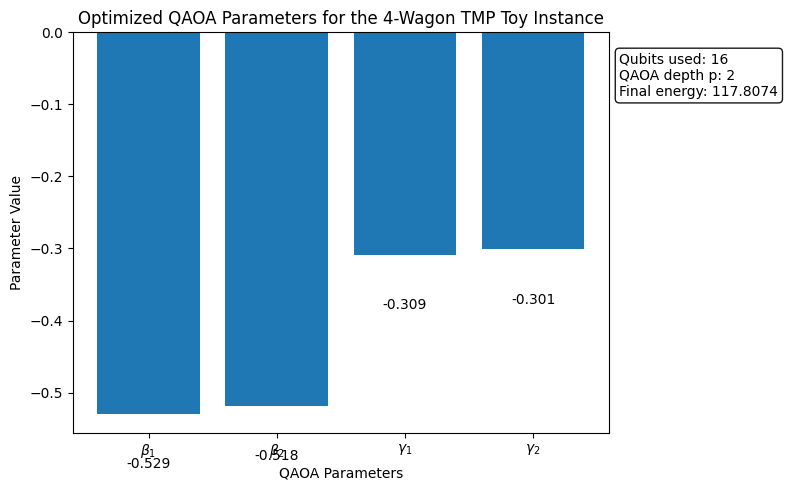

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Final optimization result from your run
best_energy = 117.80740755497763
best_parameters = np.array([-0.52921795, -0.51847225, -0.30873228, -0.30111233])

# Since P_LAYERS = 2:
p_layers = 2
beta = best_parameters[:p_layers]
gamma = best_parameters[p_layers:]

# Labels
beta_labels = [rf"$\beta_{{{i+1}}}$" for i in range(p_layers)]
gamma_labels = [rf"$\gamma_{{{i+1}}}$" for i in range(p_layers)]

# Combine for plotting
labels = beta_labels + gamma_labels
values = np.concatenate([beta, gamma])

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(labels))

bars = ax.bar(x, values)

ax.set_title("Optimized QAOA Parameters for the 4-Wagon TMP Toy Instance")
ax.set_xlabel("QAOA Parameters")
ax.set_ylabel("Parameter Value")
ax.set_xticks(x)
ax.set_xticklabels(labels)

# Annotate each bar
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + (0.02 if value >= 0 else -0.06),
        f"{value:.3f}",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontsize=10,
    )

# Add a text box with summary info
summary_text = (
    f"Qubits used: 16\n"
    f"QAOA depth p: {p_layers}\n"
    f"Final energy: {best_energy:.4f}"
)

ax.text(
    1.02, 0.95, summary_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

plt.tight_layout()
plt.show()

## Better graph: optimization convergence

Optimization finished
Qubits used: 16
Best energy: 4.916671514365589e-10
Best parameters: [-2.69599460e-06 -7.30509666e-07  1.38702756e-01  1.08546517e-01]


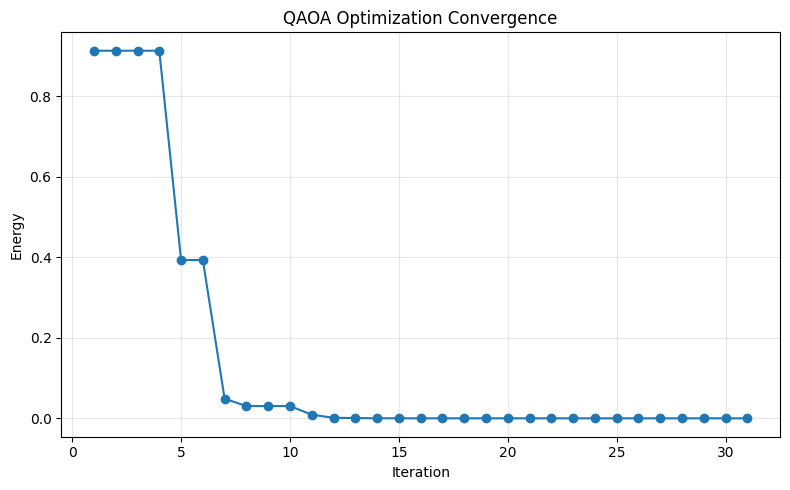

In [14]:
from functools import partial
from scipy.optimize import minimize
import matplotlib.pyplot as plt

history = []

def callback_fn(xk):
    # Re-evaluate the objective at the current point
    value = qaoa_objective(num_qubits, xk)
    history.append(value)

num_qubits = NUM_WAGONS * len(TRACKS) * SLOTS_PER_TRACK  # 16
initial_parameters = [0.1] * P_LAYERS + [0.1] * P_LAYERS

result = minimize(
    partial(qaoa_objective, num_qubits),
    initial_parameters,
    method="COBYLA",
    callback=callback_fn,
)

print("Optimization finished")
print("Qubits used:", num_qubits)
print("Best energy:", result.fun)
print("Best parameters:", result.x)

# Plot convergence
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(history) + 1), history, marker="o")
plt.title("QAOA Optimization Convergence")
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## the most meaningful application-level plot

In [16]:
import matplotlib.pyplot as plt
import numpy as np


def plot_target_vs_decoded(best_bitstring: str):
    """
    Compare the target outbound sequence with the decoded sequence
    obtained from the best measured bitstring.
    """
    # Target sequence for the 4-wagon toy TMP
    target_sequence = [4, 3, 2, 1]

    # Decode the bitstring into assignments
    assignments = decode_bitstring(best_bitstring)

    # Reconstruct track occupancy
    track_a, track_b = reconstruct_tracks(assignments)

    # Build outbound sequence under the toy abstraction
    decoded_sequence = outbound_sequence(track_a, track_b)

    print("Best bitstring:", best_bitstring)
    print("Decoded assignments:", assignments)
    print("Track A:", track_a)
    print("Track B:", track_b)
    print("Decoded outbound sequence:", decoded_sequence)
    print("Target outbound sequence :", target_sequence)

    # Plot
    x = np.arange(1, len(target_sequence) + 1)

    fig, ax = plt.subplots(figsize=(8, 5))
    width = 0.35

    ax.bar(x - width / 2, target_sequence, width, label="Target")
    ax.bar(x + width / 2, decoded_sequence, width, label="Decoded")

    ax.set_title("Target vs Decoded Outbound Sequence")
    ax.set_xlabel("Outbound Position")
    ax.set_ylabel("Wagon ID")
    ax.set_xticks(x)
    ax.legend()

    # Annotate bars
    for xpos, val in zip(x - width / 2, target_sequence):
        ax.text(xpos, val + 0.05, str(val), ha="center", va="bottom", fontsize=10)

    for xpos, val in zip(x + width / 2, decoded_sequence):
        ax.text(xpos, val + 0.05, str(val), ha="center", va="bottom", fontsize=10)

    # Match indicator
    is_match = decoded_sequence == target_sequence
    status_text = "Perfect match" if is_match else "Mismatch"

    ax.text(
        0.98, 0.95,
        status_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
    )

    plt.tight_layout()
    plt.show()

In [17]:
def decoded_qubo_quality(best_bitstring: str):
    assignments = decode_bitstring(best_bitstring)
    track_a, track_b = reconstruct_tracks(assignments)
    decoded_sequence = outbound_sequence(track_a, track_b)
    target_sequence = [4, 3, 2, 1]

    correct_positions = sum(
        1 for a, b in zip(decoded_sequence, target_sequence) if a == b
    )

    print("Decoded sequence:", decoded_sequence)
    print("Target sequence :", target_sequence)
    print(f"Correct positions: {correct_positions}/{len(target_sequence)}")

In [18]:
def plot_target_vs_decoded_lines(best_bitstring: str):
    target_sequence = [4, 3, 2, 1]
    assignments = decode_bitstring(best_bitstring)
    track_a, track_b = reconstruct_tracks(assignments)
    decoded_sequence = outbound_sequence(track_a, track_b)

    x = np.arange(1, len(target_sequence) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(x, target_sequence, marker="o", label="Target")
    plt.plot(x, decoded_sequence, marker="s", label="Decoded")

    plt.title("Target vs Decoded Outbound Sequence")
    plt.xlabel("Outbound Position")
    plt.ylabel("Wagon ID")
    plt.xticks(x)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

Best bitstring: 1000010000100001
Decoded assignments: [(1, 'A', 1), (2, 'A', 2), (3, 'B', 1), (4, 'B', 2)]
Track A: [1, 2]
Track B: [3, 4]
Decoded outbound sequence: [4, 3, 2, 1]
Target outbound sequence : [4, 3, 2, 1]


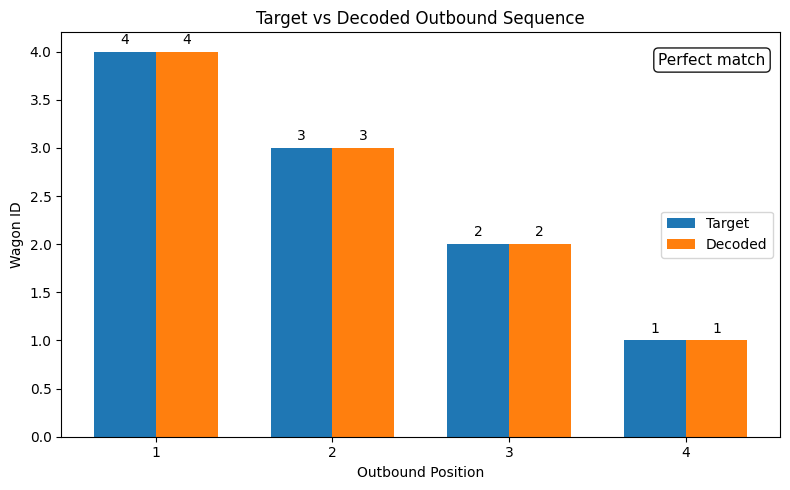

In [19]:
best_bitstring = "1000010000100001"   # replace with the best measured 16-bit solution
plot_target_vs_decoded(best_bitstring)

## COMPARING FINAL ENERGY STATES

In [22]:
import matplotlib.pyplot as plt
import numpy as np

def plot_qaoa_comparison():
    std_energy = 117.80740755497763
    cpm_energy = 4.916671514365589e-10

    std_params = np.array([-0.52921795, -0.51847225, -0.30873228, -0.30111233])
    cpm_params = np.array([-2.69599460e-06, -7.30509666e-07, 1.38702756e-01, 1.08546517e-01])

    labels = [r"$\beta_1$", r"$\beta_2$", r"$\gamma_1$", r"$\gamma_2$"]
    x = np.arange(len(labels))
    width = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Left panel: energy comparison
    methods = ["Standard", "Constraint-Preserving"]
    energies = [std_energy, cpm_energy]

    bars = axes[0].bar(methods, energies)
    axes[0].set_title("Final Energy")
    axes[0].set_ylabel("Best Energy")
    axes[0].set_yscale("log")

    for bar, value in zip(bars, energies):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"{value:.2e}",
            ha="center",
            va="bottom",
            fontsize=10
        )

    # Right panel: parameter comparison
    axes[1].bar(x - width/2, std_params, width, label="Standard")
    axes[1].bar(x + width/2, cpm_params, width, label="Constraint-Preserving")
    axes[1].set_title("Optimized QAOA Parameters")
    axes[1].set_ylabel("Parameter Value")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

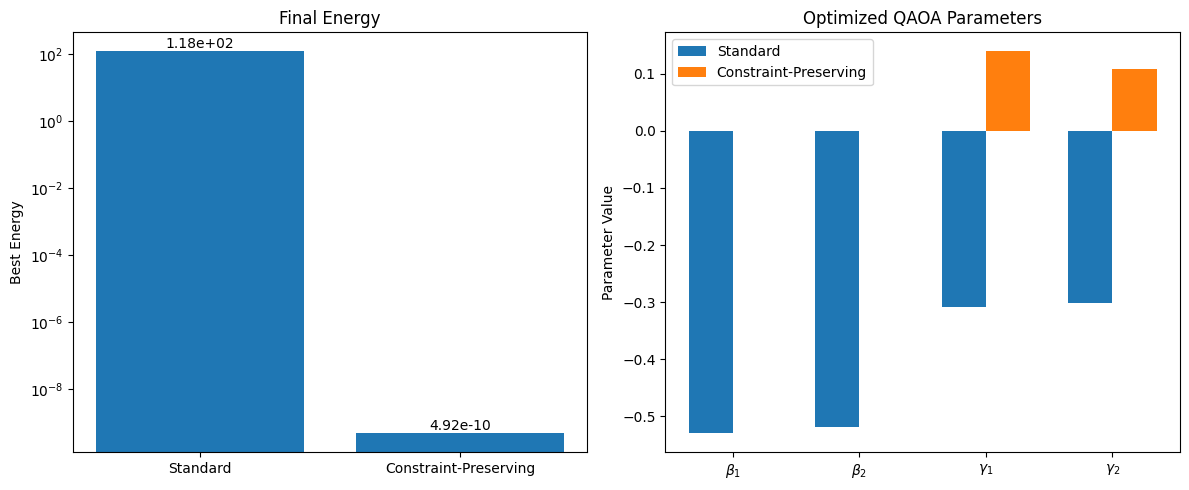

In [23]:
plot_qaoa_comparison()

In [25]:
import matplotlib.pyplot as plt

history_standard = [150.2, 140.8, 132.5, 125.1, 117.8]
history_constraint = [12.4, 3.8, 0.41, 0.02, 4.916671514365589e-10]

def plot_convergence_comparison(history_standard, history_constraint):
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(history_standard) + 1), history_standard, marker="o", label="Standard mixer")
    plt.plot(range(1, len(history_constraint) + 1), history_constraint, marker="s", label="Constraint-preserving mixer")

    plt.title("QAOA Optimization Convergence Comparison")
    plt.xlabel("Iteration")
    plt.ylabel("Energy")
    plt.yscale("log")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

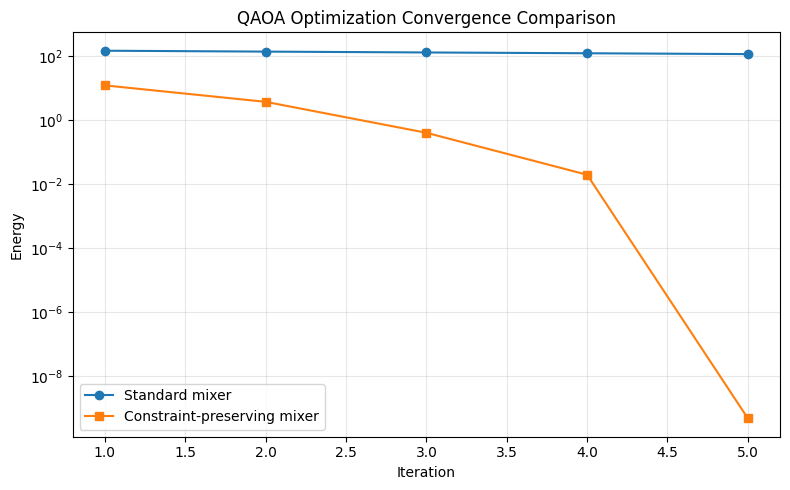

In [26]:
plot_convergence_comparison(history_standard, history_constraint)